In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

# Resposta a uma entrada qualquer

Considere o sistema:

\begin{align}
	y\left[n\right] - 0.6 y\left[n-1\right] -0.16  y\left[n\right] = 5 x\left[n\right]
\end{align}

Determine a resposta à entrada:
\begin{align}
	x\left[n\right] = 4^{-n} ~ u \left[n\right]
\end{align}


n = [-2 -1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
x = [0.00000000e+00 0.00000000e+00 1.00000000e+00 2.50000000e-01
 6.25000000e-02 1.56250000e-02 3.90625000e-03 9.76562500e-04
 2.44140625e-04 6.10351562e-05 1.52587891e-05 3.81469727e-06
 9.53674316e-07 2.38418579e-07 5.96046448e-08 1.49011612e-08
 3.72529030e-09 9.31322575e-10 2.32830644e-10 5.82076609e-11
 1.45519152e-11 3.63797881e-12]
h = [0.         0.         5.         4.25       3.6625     2.955625
 2.37890625 1.90512656 1.52492164 1.22007841 0.9761108  0.7808981
 0.62472136 0.4997777  0.39982234 0.31985791 0.25588634 0.20470907
 0.16376726 0.13101381 0.10481105 0.08384884]


<StemContainer object of 3 artists>

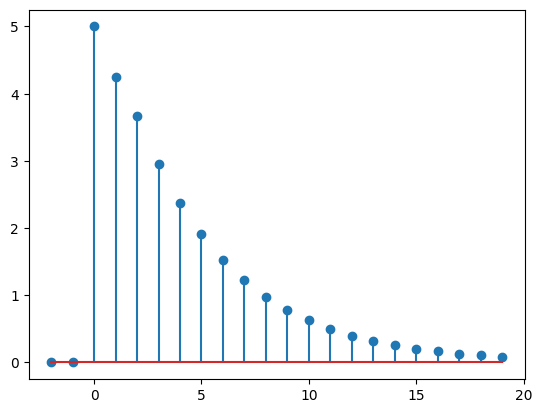

In [2]:
#Opção 1: utilizar o sistema diretamente
n = np.arange(-2, 20, 1)
x = (1/4) ** n 
x[0] = 0
x[1] = 0

y = np.zeros_like(n, dtype=float)

for k in range(2,len(n)):
    y[k] = 0.16 * y[k-2] + 0.6 * y[k-1] + 5 * x[k]
    
print(f'n = {n}')
print(f'x = {x}')
print(f'h = {y}')

plt.stem(n, y)

## Cálculo pela resposta ao impulso #

Podemos escrever a entrada $x\left[n\right]$ como um somatório de impulsos. No exemplo:

\begin{align}
	x\left[n\right] &= 4^{-n} u\left[\right] \\
    &= 1 \cdot \delta\left[n\right] + \frac{1}{4} \cdot \delta\left[n - 1\right] + \frac{1}{16} \cdot \delta\left[n - 2\right] + \frac{1}{64} \cdot \delta\left[n - 3\right]...
\end{align}

Em outras palavras:

\begin{align}
    x\left[n\right] &= \sum_{m = -\infty}^{\infty} x\left[m\right] ~ \delta\left[n-m\right]
\end{align}

Pela linearidade, sabemos que:

\begin{align}
    \delta\left[n\right] \rightarrow h\left[n\right]
\end{align}

Isto é, a saída para uma entrada do tipo impulso unitário é a resposta ao impulso do sistema. Mais ainda, sabemos que:

\begin{align}
   x\left[m\right] ~ \delta\left[n\right] \rightarrow x\left[m\right] ~ h\left[n\right]
\end{align}

Isto é, uma entrada que é um impulso multiplicado por uma constante ($x\left[m\right]$ é uma constante em n) é a resposta ao impulso multiplicada por esta constante. Atrasando o impulso tempos apenas atrasos desta resposta ao impulso:

\begin{align}
   x\left[m\right] ~ \delta\left[n - m\right] \rightarrow x\left[m\right] ~ h\left[n - m\right]
\end{align}

Podemos expandir esta ideia para os primeiros termos:

\begin{align}
   x\left[0\right] ~ \delta\left[n\right] &\rightarrow x\left[0\right] ~ h\left[n\right] \\
   x\left[1\right] ~ \delta\left[n - 1\right] &\rightarrow x\left[1\right] ~ h\left[n - 1\right] \\
   x\left[2\right] ~ \delta\left[n - 2\right] &\rightarrow x\left[2\right] ~ h\left[n - 2\right] \\
   x\left[3\right] ~ \delta\left[n - 3\right] &\rightarrow x\left[3\right] ~ h\left[n - 3\right] \\
\end{align}

E assim vai.

Ou seja, sabemos que a saída é dada por:
\begin{align}
y\left[n\right] = \sum_{m = -\infty}^{\infty} x\left[m\right] ~ h\left[ n-m \right]
\end{align}

Ou seja, a saída vai ser dada por:
\begin{align}
y\left[n\right] = x\left[0\right] ~ h\left[n\right] + x\left[1\right] ~ h\left[n - 1\right] + x\left[2\right] ~ h\left[n - 2\right] + x\left[3\right] ~ h\left[n - 3\right]...
\end{align}

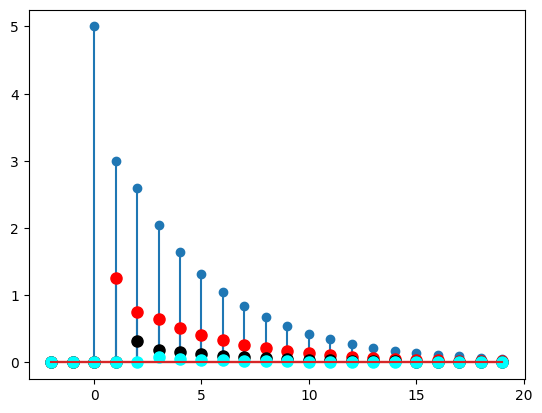

In [3]:
#Exemplo 2
x0 = 1
x1 = 1/4
x2 = 1/16
x3 = 1/64

h = np.zeros_like(n, dtype=float)
h = 4 * (0.8) ** n + (-0.2)** n
h[0] = 0
h[1] = 0

y0 = x0 * h
markerline, stemlines, baseline = plt.stem(n, y0)

hminus1 =  np.concatenate((np.array([0],dtype=float), h[:-1]))
y1 = x1 * hminus1
markerline1, stemlines1, baseline1 = plt.stem(n, y1)
plt.setp(markerline1, color='red', markersize=8)  # Marker color

hminus2 =  np.concatenate((np.array([0],dtype=float), hminus1[:-1]))
y2 = x2 * hminus2
markerline2, stemlines2, baseline2 = plt.stem(n, y2)
plt.setp(markerline2, color='black', markersize=8)  # Marker color

hminus3 =  np.concatenate((np.array([0],dtype=float), hminus2[:-1]))
y3 = x3 * hminus3
markerline3, stemlines3, baseline3 = plt.stem(n, y3)
plt.setp(markerline3, color='cyan', markersize=8)  # Marker color



plt.show()


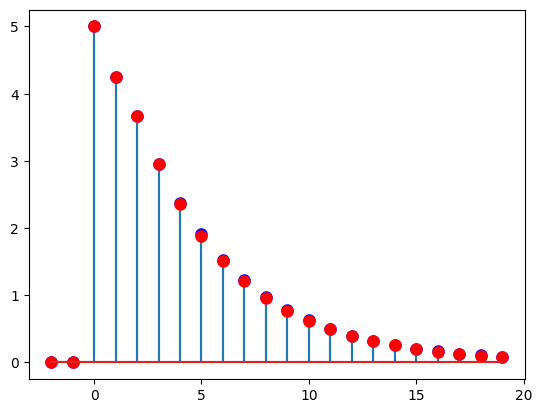

Recursiva | Somatório
0.000000  |  0.000000
0.000000  |  0.000000
5.000000  |  5.000000
4.250000  |  4.250000
3.662500  |  3.662500
2.955625  |  2.955625
2.378906  |  2.359375
1.905127  |  1.888525
1.524922  |  1.510615
1.220078  |  1.208533
0.976111  |  0.966818
0.780898  |  0.773456
0.624721  |  0.618765
0.499778  |  0.495012
0.399822  |  0.396009
0.319858  |  0.316808
0.255886  |  0.253446
0.204709  |  0.202757
0.163767  |  0.162205
0.131014  |  0.129764
0.104811  |  0.103811
0.083849  |  0.083049


In [4]:
#O resultado é apenas a soma destes elementos.

yn = y0 + y1 + y2 + y3

markerline, stemlines, baseline = plt.stem(n, y)
plt.setp(markerline, color='blue', markersize=8)  # Marker color

markerline1, stemlines1, baseline1 = plt.stem(n, yn)
plt.setp(markerline1, color='red', markersize=8)  # Marker color

plt.show()

print(f'Recursiva | Somatório')
for k in range(len(n)):
    print(f'{y[k]:.6f}  |  {yn[k]:.6f}')

Note que as primeiras quatro amostras são exatamente iguais, e que a partir desta amostra elas começam a divergir. Isso ocorreu porque eu calculei apenas 4 elementos do somatório.

Podemos calcular o valor final como sendo a convolução entre a entrada $x\left[n\right]$ e a resposta ao impulso $h\left[n\right]$.


[1.00000000e+00 2.50000000e-01 6.25000000e-02 1.56250000e-02
 3.90625000e-03 9.76562500e-04 2.44140625e-04 6.10351562e-05
 1.52587891e-05 3.81469727e-06 9.53674316e-07 2.38418579e-07
 5.96046448e-08 1.49011612e-08 3.72529030e-09 9.31322575e-10
 2.32830644e-10 5.82076609e-11 1.45519152e-11 3.63797881e-12]
[5.         3.         2.6        2.04       1.64       1.3104
 1.04864    0.838848   0.6710912  0.5368704  0.42949683 0.34359736
 0.27487791 0.21990232 0.17592186 0.14073749 0.11258999 0.09007199
 0.07205759 0.05764608]
Recursiva | Convolução
5.000000  |  5.000000
4.250000  |  4.250000
3.662500  |  3.662500
2.955625  |  2.955625
2.378906  |  2.378906
1.905127  |  1.905127
1.524922  |  1.524922
1.220078  |  1.220078
0.976111  |  0.976111
0.780898  |  0.780898
0.624721  |  0.624721
0.499778  |  0.499778
0.399822  |  0.399822
0.319858  |  0.319858
0.255886  |  0.255886
0.204709  |  0.204709
0.163767  |  0.163767
0.131014  |  0.131014
0.104811  |  0.104811
0.083849  |  0.083849


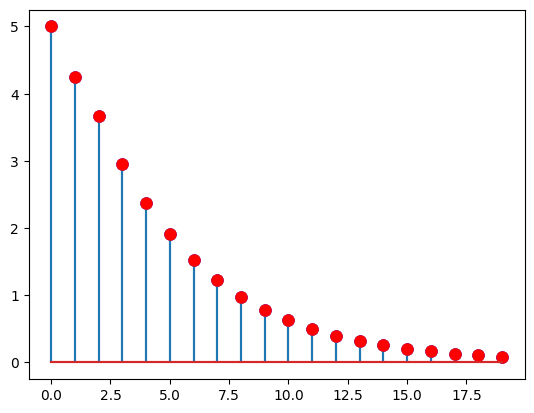

In [5]:
#Calculando a convolução.
n = np.arange(0, 20, 1)
x = (1/4) ** n 
h = 4 * (0.8) ** n + (-0.2)** n

yconv = np.zeros_like(x, dtype=float)

print(x)
print(h)

for k in range(len(x)):
    tempSum = 0
    for m in range(k+1):
        tempSum += x[m] * h[k - m]
    yconv[k] = tempSum

#Note que vetor original de y tinha os valores para y[-1] e y[-2]. Como eu apenas calculei a partir de n=0 aqui, eu estou
#removendo os dois primeiros elementos (y[2:] em python)
markerline, stemlines, baseline = plt.stem(n, y[2:])
plt.setp(markerline, color='blue', markersize=8)  # Marker color

markerline1, stemlines1, baseline1 = plt.stem(n, yconv)
plt.setp(markerline1, color='red', markersize=8)  # Marker color


print(f'Recursiva | Convolução')
for k in range(len(n)):
    print(f'{y[k+2]:.6f}  |  {yconv[k]:.6f}')